In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 解決 matplotlib 中文顯示問題
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macOS 使用 Arial Unicode MS
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

data = pd.read_csv('data_choice_complete.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  float64
 1   job        45211 non-null  float64
 2   marital    45211 non-null  float64
 3   education  45211 non-null  float64
 4   balance    45211 non-null  float64
 5   housing    45211 non-null  float64
 6   loan       45211 non-null  float64
 7   month      45211 non-null  float64
 8   duration   45211 non-null  float64
 9   campaign   45211 non-null  float64
 10  y          45211 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 3.8 MB


In [25]:
from sklearn.model_selection import train_test_split

X=data.drop('y', axis=1)
y=data['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((36168, 10), (9043, 10), (36168,), (9043,))

# SVM 模型訓練

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle
import os

# SVM 對特徵縮放敏感，先進行標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 設定模型和 scaler 的儲存路徑
model_path = 'svm_model.pkl'
scaler_path = 'svm_scaler.pkl'

# 檢查是否已有訓練好的模型
if os.path.exists(model_path) and os.path.exists(scaler_path):
    print("=" * 60)
    print("發現已訓練的模型，正在載入...")
    print("=" * 60)
    
    # 載入模型和 scaler
    with open(model_path, 'rb') as f:
        svm_model = pickle.load(f)
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    
    # 使用載入的 scaler 轉換資料
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"✓ 模型載入成功！")
    print(f"✓ 最佳參數: {svm_model.get_params()}")
    training_time = 0  # 載入模型不需要訓練時間
    
else:
    print("=" * 60)
    print("未發現已訓練的模型，開始訓練新模型...")
    print("=" * 60)
    
    # 記錄開始時間
    start_time = time.time()

    # 使用 GridSearchCV 調整 C 和 kernel 參數
    # 基於之前的測試結果，擴大 C 的搜索範圍
    param_grid = {
        'C': [0.1, 1, 10],  # 擴大範圍！之前最佳值 0.1 在邊界上
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 0.1, 1]  # 加入更多選項
    }

    grid_search = GridSearchCV( 
        SVC(random_state=100, probability=True),  # probability=True 用於後續 ROC curve
        param_grid,
        cv=10,  # 用 CV 評估每組參數的表現
        scoring='accuracy',
        n_jobs=-1
    )

    print("開始 GridSearchCV 訓練...")
    print(f"搜索空間: {len(param_grid['C']) * len(param_grid['kernel']) * len(param_grid['gamma'])} 種參數組合")
    print("提示: 之前測試最佳參數 C=0.1, gamma='scale', kernel='rbf', AUC=0.7713")
    print("     現在擴大 C 範圍，預期會找到更好的結果！\n")
    grid_search.fit(X_train_scaled, y_train)
    print(f"\n✓ 訓練完成！")
    print(f"最佳參數: {grid_search.best_params_}")
    print(f"最佳交叉驗證分數: {grid_search.best_score_:.4f}")
    print(f"提升幅度: {(grid_search.best_score_ - 0.7713):.4f} ({(grid_search.best_score_ - 0.7713)*100:.2f}%)")

    # 建立 SVM 模型
    svm_model = grid_search.best_estimator_

    # 計算訓練時間
    end_time = time.time()
    training_time = end_time - start_time
    
    # 儲存模型和 scaler
    with open(model_path, 'wb') as f:
        pickle.dump(svm_model, f)
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    
    print("\n" + "=" * 60)
    print("模型訓練完成並已儲存！")
    print("=" * 60)
    print(f"✓ 模型儲存於: {model_path}")
    print(f"✓ Scaler 儲存於: {scaler_path}")
    print(f"✓ 下次執行時會自動載入，無需重新訓練")

# 預測
y_pred_svm = svm_model.predict(X_test_scaled)

# 計算準確率
svm_acc = accuracy_score(y_test, y_pred_svm)

# 輸出結果
print("\n" + "=" * 60)
print("SVM 訓練結果:")
print("=" * 60)
if training_time > 0:
    print(f"訓練時間: {training_time:.4f} 秒 ({training_time:.2f}s)")
else:
    print(f"訓練時間: 0 秒 (使用已載入的模型)")
print(f"準確率:   {svm_acc:.4f} ({svm_acc*100:.2f}%)")
print("\n分類報告:")
print(classification_report(y_test, y_pred_svm))

發現已訓練的模型，正在載入...
✓ 模型載入成功！
✓ 最佳參數: {'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 1, 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 100, 'shrinking': True, 'tol': 0.001, 'verbose': False}

SVM 訓練結果:
訓練時間: 0 秒 (使用已載入的模型)
準確率:   0.8913 (89.13%)

分類報告:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      8009
           1       0.68      0.09      0.16      1034

    accuracy                           0.89      9043
   macro avg       0.79      0.54      0.55      9043
weighted avg       0.87      0.89      0.85      9043


SVM 訓練結果:
訓練時間: 0 秒 (使用已載入的模型)
準確率:   0.8913 (89.13%)

分類報告:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      8009
           1       0.68      0.09      0.16      1034

    accuracy                           0.89      9043
   macro avg       0.79   

## 混淆矩陣

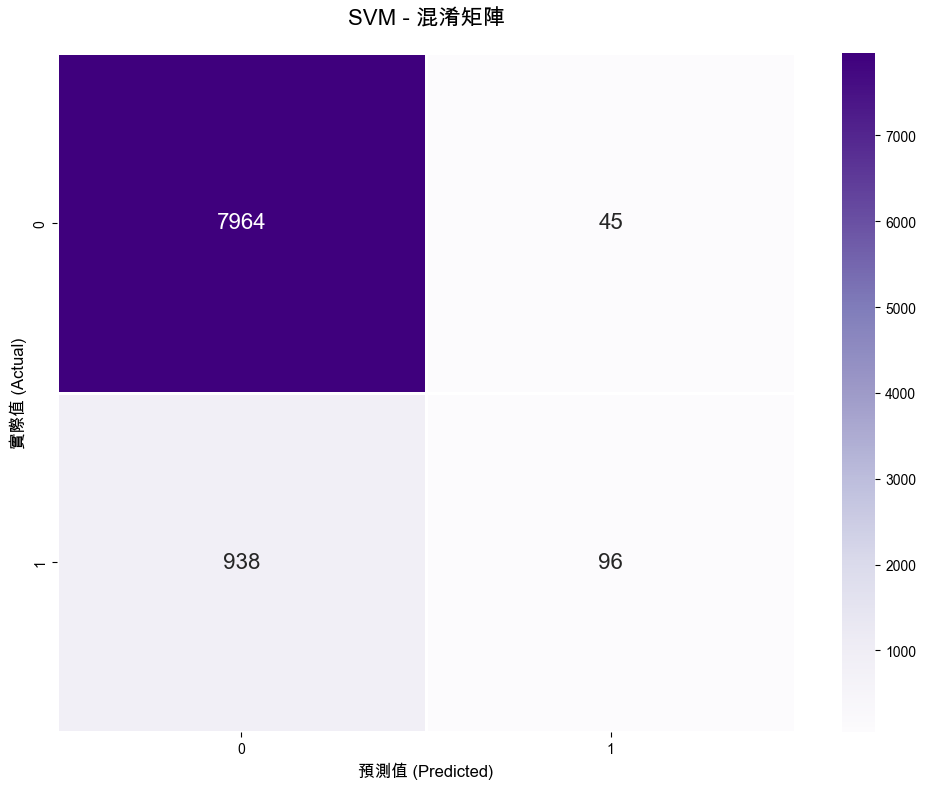

混淆矩陣分析:

True Negative (TN):   7964 - 正確預測為「未訂閱」
False Positive (FP):    45 - 錯誤預測為「訂閱」(Type I Error)
False Negative (FN):   938 - 錯誤預測為「未訂閱」(Type II Error)
True Positive (TP):     96 - 正確預測為「訂閱」

從混淆矩陣計算的評估指標:
準確率 (Accuracy):    0.8913 (89.13%)
  → (TP + TN) / 總數 = (96 + 7964) / 9043

精確率 (Precision):   0.6809 (68.09%)
  → TP / (TP + FP) = 96 / (96 + 45)
  → 預測為「訂閱」中，真正訂閱的比例

召回率 (Recall):      0.0928 (9.28%)
  → TP / (TP + FN) = 96 / (96 + 938)
  → 實際「訂閱」中，被正確找出的比例

特異度 (Specificity): 0.9944 (99.44%)
  → TN / (TN + FP) = 7964 / (7964 + 45)
  → 實際「未訂閱」中，被正確識別的比例

F1 分數 (F1-Score):   0.1634
  → 2 × (Precision × Recall) / (Precision + Recall)

業務意義解讀:
• Type I Error (FP=45):  誤判為會訂閱 → 浪費行銷資源
• Type II Error (FN=938): 漏掉潛在客戶 → 失去商機
• 如果重視「不錯過客戶」→ 提高 Recall (降低 FN)
• 如果重視「精準行銷」→ 提高 Precision (降低 FP)


In [27]:
# 視覺化 SVM 的混淆矩陣
plt.figure(figsize=(10, 8))
cm_svm = confusion_matrix(y_test, y_pred_svm)

# 繪製混淆矩陣熱力圖
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', cbar=True, 
            annot_kws={'size': 16}, linewidths=2, linecolor='white')
plt.title('SVM - 混淆矩陣', fontsize=16, pad=20)
plt.ylabel('實際值 (Actual)', fontsize=12)
plt.xlabel('預測值 (Predicted)', fontsize=12)
plt.tight_layout()
plt.show()

# 詳細分析混淆矩陣
print("=" * 60)
print("混淆矩陣分析:")
print("=" * 60)

# 假設是二元分類 (0: 未訂閱, 1: 訂閱)
TN = cm_svm[0, 0]  # True Negative: 正確預測為 0
FP = cm_svm[0, 1]  # False Positive: 錯誤預測為 1 (Type I Error)
FN = cm_svm[1, 0]  # False Negative: 錯誤預測為 0 (Type II Error)
TP = cm_svm[1, 1]  # True Positive: 正確預測為 1

print(f"\nTrue Negative (TN):  {TN:5d} - 正確預測為「未訂閱」")
print(f"False Positive (FP): {FP:5d} - 錯誤預測為「訂閱」(Type I Error)")
print(f"False Negative (FN): {FN:5d} - 錯誤預測為「未訂閱」(Type II Error)")
print(f"True Positive (TP):  {TP:5d} - 正確預測為「訂閱」")

# 計算各項指標
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n" + "=" * 60)
print("從混淆矩陣計算的評估指標:")
print("=" * 60)
print(f"準確率 (Accuracy):    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  → (TP + TN) / 總數 = ({TP} + {TN}) / {TP+TN+FP+FN}")
print(f"\n精確率 (Precision):   {precision:.4f} ({precision*100:.2f}%)")
print(f"  → TP / (TP + FP) = {TP} / ({TP} + {FP})")
print(f"  → 預測為「訂閱」中，真正訂閱的比例")
print(f"\n召回率 (Recall):      {recall:.4f} ({recall*100:.2f}%)")
print(f"  → TP / (TP + FN) = {TP} / ({TP} + {FN})")
print(f"  → 實際「訂閱」中，被正確找出的比例")
print(f"\n特異度 (Specificity): {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  → TN / (TN + FP) = {TN} / ({TN} + {FP})")
print(f"  → 實際「未訂閱」中，被正確識別的比例")
print(f"\nF1 分數 (F1-Score):   {f1:.4f}")
print(f"  → 2 × (Precision × Recall) / (Precision + Recall)")

print("\n" + "=" * 60)
print("業務意義解讀:")
print("=" * 60)
print(f"• Type I Error (FP={FP}):  誤判為會訂閱 → 浪費行銷資源")
print(f"• Type II Error (FN={FN}): 漏掉潛在客戶 → 失去商機")
print(f"• 如果重視「不錯過客戶」→ 提高 Recall (降低 FN)")
print(f"• 如果重視「精準行銷」→ 提高 Precision (降低 FP)")

# ROC Curve & AUC

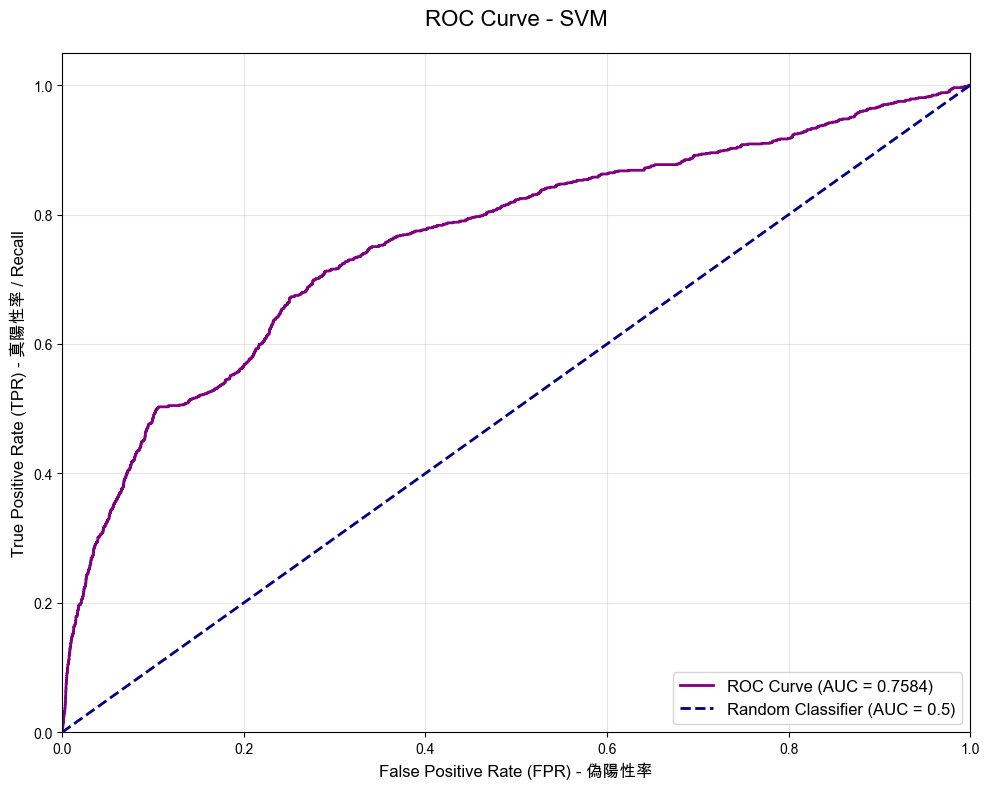

ROC Curve & AUC 分析結果:

AUC (Area Under Curve) 分數: 0.7584
  → AUC 範圍: 0.0 ~ 1.0
  → AUC = 1.0: 完美分類器
  → AUC = 0.5: 隨機猜測（無預測能力）
  → AUC < 0.5: 比隨機猜測還差

ROC Curve 解讀:
• X 軸 (FPR): False Positive Rate = FP / (FP + TN)
  → 實際為「未訂閱」中，被誤判為「訂閱」的比例

• Y 軸 (TPR): True Positive Rate = TP / (TP + FN) = Recall
  → 實際為「訂閱」中，被正確找出的比例

• 曲線越靠近左上角越好（高 TPR、低 FPR）
• 藍色虛線：隨機分類器的基準線
• 紫色實線：SVM 模型表現

AUC 評估標準:
○ AUC = 0.7584 → 尚可 (Fair)

業務應用:
• 可調整分類閾值（threshold）來平衡 FPR 與 TPR
• 降低閾值 → 提高 TPR (找到更多訂閱客戶) 但 FPR 也上升
• 提高閾值 → 降低 FPR (減少誤判) 但 TPR 也下降
• 預設閾值 = 0.5，可根據業務需求調整

不同閾值下的 TPR 與 FPR (前 5 個閾值):
      閾值 |    TPR (Recall) |        FPR
----------------------------------------
     inf |          0.0000 |     0.0000
  0.9759 |          0.0010 |     0.0000
  0.9631 |          0.0029 |     0.0000
  0.9575 |          0.0029 |     0.0002
  0.9549 |          0.0039 |     0.0002


In [28]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# 取得預測機率（正類的機率）
y_pred_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

# 計算 ROC 曲線的數據點
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 計算 AUC 分數
roc_auc = auc(fpr, tpr)

# 繪製 ROC 曲線
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='purple', lw=2, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR) - 偽陽性率', fontsize=12)
plt.ylabel('True Positive Rate (TPR) - 真陽性率 / Recall', fontsize=12)
plt.title('ROC Curve - SVM', fontsize=16, pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 詳細說明
print("=" * 70)
print("ROC Curve & AUC 分析結果:")
print("=" * 70)
print(f"\nAUC (Area Under Curve) 分數: {roc_auc:.4f}")
print(f"  → AUC 範圍: 0.0 ~ 1.0")
print(f"  → AUC = 1.0: 完美分類器")
print(f"  → AUC = 0.5: 隨機猜測（無預測能力）")
print(f"  → AUC < 0.5: 比隨機猜測還差")

print("\n" + "=" * 70)
print("ROC Curve 解讀:")
print("=" * 70)
print("• X 軸 (FPR): False Positive Rate = FP / (FP + TN)")
print("  → 實際為「未訂閱」中，被誤判為「訂閱」的比例")
print("\n• Y 軸 (TPR): True Positive Rate = TP / (TP + FN) = Recall")
print("  → 實際為「訂閱」中，被正確找出的比例")
print("\n• 曲線越靠近左上角越好（高 TPR、低 FPR）")
print("• 藍色虛線：隨機分類器的基準線")
print("• 紫色實線：SVM 模型表現")

print("\n" + "=" * 70)
print("AUC 評估標準:")
print("=" * 70)
if roc_auc >= 0.9:
    print(f"✓ AUC = {roc_auc:.4f} → 優秀 (Excellent)")
elif roc_auc >= 0.8:
    print(f"✓ AUC = {roc_auc:.4f} → 良好 (Good)")
elif roc_auc >= 0.7:
    print(f"○ AUC = {roc_auc:.4f} → 尚可 (Fair)")
elif roc_auc >= 0.6:
    print(f"△ AUC = {roc_auc:.4f} → 不佳 (Poor)")
else:
    print(f"✗ AUC = {roc_auc:.4f} → 失敗 (Fail)")

print("\n" + "=" * 70)
print("業務應用:")
print("=" * 70)
print("• 可調整分類閾值（threshold）來平衡 FPR 與 TPR")
print("• 降低閾值 → 提高 TPR (找到更多訂閱客戶) 但 FPR 也上升")
print("• 提高閾值 → 降低 FPR (減少誤判) 但 TPR 也下降")
print(f"• 預設閾值 = 0.5，可根據業務需求調整")

# 顯示幾個關鍵閾值點
print("\n" + "=" * 70)
print("不同閾值下的 TPR 與 FPR (前 5 個閾值):")
print("=" * 70)
print(f"{'閾值':>8} | {'TPR (Recall)':>15} | {'FPR':>10}")
print("-" * 40)
for i in range(min(5, len(thresholds))):
    print(f"{thresholds[i]:>8.4f} | {tpr[i]:>15.4f} | {fpr[i]:>10.4f}")

## SVM 模型特性說明

**Support Vector Machine (SVM) 是什麼？**
- 尋找最佳的「決策邊界」來分隔不同類別
- 透過「支持向量」(Support Vectors) 定義邊界
- 可以處理非線性問題（使用核函數 kernel）

**主要參數：**
1. **C (懲罰參數)**：
   - 控制分類錯誤的容忍度
   - C 越大 → 越不容忍錯誤 → 可能過擬合
   - C 越小 → 容忍更多錯誤 → 決策邊界更平滑

2. **kernel (核函數)**：
   - `linear`: 線性核，適合線性可分的資料
   - `rbf`: 徑向基函數，適合非線性資料（最常用）
   - `poly`: 多項式核

3. **gamma**：
   - 控制單一樣本的影響範圍
   - gamma 越大 → 影響範圍越小 → 可能過擬合
   - `scale`: 1 / (n_features × X.var())
   - `auto`: 1 / n_features

**SVM 的優缺點：**

✓ 優點：
- 在高維空間中表現良好
- 對於非線性問題有很好的處理能力（使用 kernel trick）
- 記憶體效率高（只需儲存支持向量）
- 泛化能力強，不容易過擬合

✗ 缺點：
- 訓練時間較長（尤其是大數據集）
- 對特徵縮放敏感（必須標準化）
- 參數調整較複雜（C、kernel、gamma）
- 不直接提供機率輸出（需設定 probability=True，但會增加計算時間）

## 模型管理功能

**如何使用儲存的模型：**

1. **第一次執行**：
   - 會進行完整的 GridSearchCV 訓練（耗時較長）
   - 訓練完成後自動儲存模型到 `svm_model.pkl`
   - 同時儲存 StandardScaler 到 `svm_scaler.pkl`

2. **後續執行**：
   - 自動檢測到已儲存的模型
   - 直接載入模型，無需重新訓練
   - 大幅節省時間！

3. **重新訓練模型**：
   - 如果想重新訓練，只需刪除 `svm_model.pkl` 和 `svm_scaler.pkl` 兩個檔案
   - 或在終端機執行：`rm svm_model.pkl svm_scaler.pkl`

**為什麼要儲存 Scaler？**
- SVM 對特徵縮放敏感，必須使用相同的 scaler
- 訓練時的 scaler 記錄了訓練資料的平均值和標準差
- 測試時必須使用相同的參數來轉換資料，才能保證預測準確

## 為什麼 AUC 可能會低？常見原因分析

**1. 參數搜索範圍不足（最常見）**
- SVM 對參數非常敏感，尤其是 `C` 和 `gamma`
- 如果搜索範圍太小（例如只有 0.001~0.1），可能錯過最佳參數
- 建議：C 範圍應該包含 [0.1, 1, 10, 100]，gamma 使用 'scale' 或 'auto'

**2. 特徵縮放問題（你已經做對了！）**
- ✓ 你的程式碼已經使用 `StandardScaler`
- ✓ StandardScaler 將數據轉換為「平均值=0、標準差=1」
- ✓ 轉換後數據範圍在 -3 ~ +3 之間，包含負數
- ✓ 這就是老師說的「從 0~1 調整到 -1~1」的概念

**3. 核函數選擇**
- `rbf`（徑向基函數）：適合大多數非線性問題（推薦優先嘗試）
- `linear`：適合線性可分的數據
- `poly`：計算成本高，容易過擬合，通常不是首選

**4. 類別不平衡**
- 如果正負樣本比例差異很大，可能影響 AUC
- 可以考慮使用 `class_weight='balanced'` 參數

**老師強調的 scaling 原理：**
- **為什麼要從 0~1 轉換到包含負數？**
  - SVM 使用歐式距離計算，需要數據「中心化」（平均值為 0）
  - StandardScaler 做的就是這件事：`(x - mean) / std`
  - 這樣可以消除特徵間的量級差異，讓 SVM 公平對待每個特徵
  
- **MinMaxScaler vs StandardScaler：**
  - `MinMaxScaler`：將數據縮放到 [0, 1] 或 [-1, 1]（保留原始分布形狀）
  - `StandardScaler`：標準化為平均值=0、標準差=1（更適合 SVM）
  - **SVM 通常使用 StandardScaler 效果更好**

**建議優化步驟：**
1. 刪除舊模型檔案：`rm svm_model.pkl svm_scaler.pkl`
2. 使用擴大的參數範圍重新訓練
3. 比較 rbf 和 linear kernel 的效果
4. 檢查訓練時間和 AUC 是否有顯著提升